In [ ]:
from google.colab import files
uploaded=files.upload()

Saving home_data.csv to home_data.csv


In [ ]:
import pandas as pd

  # Lấy tên file đã tải lên
df = pd.read_csv('home_data.csv')

In [ ]:
import pandas as pd

# Lấy tên file đã tải lên
df = pd.read_csv('home_data.csv')

# Hiển thị số lượng dòng và cột
num_rows, num_cols = df.shape
print(f"Số lượng dòng: {num_rows}")
print(f"Số lượng cột: {num_cols}")

# Hiển thị số lượng kiểu dữ liệu
num_data_types = len(df.dtypes.unique())
print(f"Số lượng kiểu dữ liệu: {num_data_types}")

# Hiển thị bộ nhớ lưu trữ
memory_usage = df.memory_usage(deep=True).sum()
print(f"Bộ nhớ lưu trữ: {memory_usage} bytes")

# Hiển thị k mẫu dữ liệu đầu tiên (ví dụ k=5)
k = 5
print(f"\n{k} mẫu dữ liệu đầu tiên:")
display(df.head(k))

Số lượng dòng: 1054
Số lượng cột: 22
Số lượng kiểu dữ liệu: 2
Bộ nhớ lưu trữ: 185636 bytes

5 mẫu dữ liệu đầu tiên:


,num_bed,year_built,longitude,latitude,num_room,num_bath,living_area,property_type,num_parking,accessible_buildings,...,emergency_shelters,emergency_water,Facilities,fire_stations,Cultural,Monuments,police_stations,Vacant,Free_Parking,askprice
0,2,1993,-73.669677,45.537392,5.0,1,97.55,9,1,5,...,26,185,11,26,42,14,15,1,36,272800
1,2,2003,-73.565143,45.492742,5.0,1,94.02,9,1,5,...,27,213,216,37,62,41,17,43,48,421000
2,2,1996,-73.625817,45.498158,7.0,2,93.37,9,1,5,...,36,284,210,40,73,44,23,43,51,364000
3,2,2002,-73.553805,45.499028,4.0,1,78.97,9,1,4,...,25,199,216,34,61,41,18,43,49,420000
4,5,1946,-73.624906,45.505063,9.0,3,167.23,9,1,5,...,35,294,210,42,75,45,24,43,52,719000


In [ ]:
# Kiểm tra hình dạng của dataframe 556 dòng, 22 cột
print("Shape of the DataFrame:", df.shape)

# Kiểm tra kiểu dữ liệu từng cột
print("\nData Types of each column:\n", df.dtypes)

# Tóm tắt thống kê mô tả của các đặc trưng số học.
print("\nDescriptive Statistics of Numerical Features:\n", df.describe())

# Xác định và đếm số giá trị bị thiếu trong mỗi cột.
missing_values = df.isnull().sum()
print("\nMissing Values per column:\n", missing_values)

# Xác định tỷ lệ giá trị bị thiếu trong mỗi cột.
missing_proportion = (missing_values / len(df)) * 100
print("\nProportion of Missing Values per column:\n", missing_proportion)



Shape of the DataFrame: (1054, 22)

Data Types of each column:
 num_bed                   int64
year_built                int64
longitude               float64
latitude                float64
num_room                float64
num_bath                  int64
living_area             float64
property_type             int64
num_parking               int64
accessible_buildings      int64
family_quality            int64
art_expos                 int64
emergency_shelters        int64
emergency_water           int64
Facilities                int64
fire_stations             int64
Cultural                  int64
Monuments                 int64
police_stations           int64
Vacant                    int64
Free_Parking              int64
askprice                  int64
dtype: object

Descriptive Statistics of Numerical Features:
            num_bed   year_built    longitude     latitude     num_room  \
count  1054.000000  1054.000000  1054.000000  1054.000000  1054.000000   
mean      1.982922  19

In [ ]:
# Chuyển kiểu dữ liệu các cột thành kiểu dữ liệu đúng
for col in ['num_bed', 'year_built', 'longitude']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Xử lý các giá trị bị mất (simple imputation for demonstration)
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())
    elif df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

# Hiện thị thông tin
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_bed               1054 non-null   int64  
 1   year_built            1054 non-null   int64  
 2   longitude             1054 non-null   float64
 3   latitude              1054 non-null   float64
 4   num_room              1054 non-null   float64
 5   num_bath              1054 non-null   int64  
 6   living_area           1054 non-null   float64
 7   property_type         1054 non-null   int64  
 8   num_parking           1054 non-null   int64  
 9   accessible_buildings  1054 non-null   int64  
 10  family_quality        1054 non-null   int64  
 11  art_expos             1054 non-null   int64  
 12  emergency_shelters    1054 non-null   int64  
 13  emergency_water       1054 non-null   int64  
 14  Facilities            1054 non-null   int64  
 15  fire_stations        

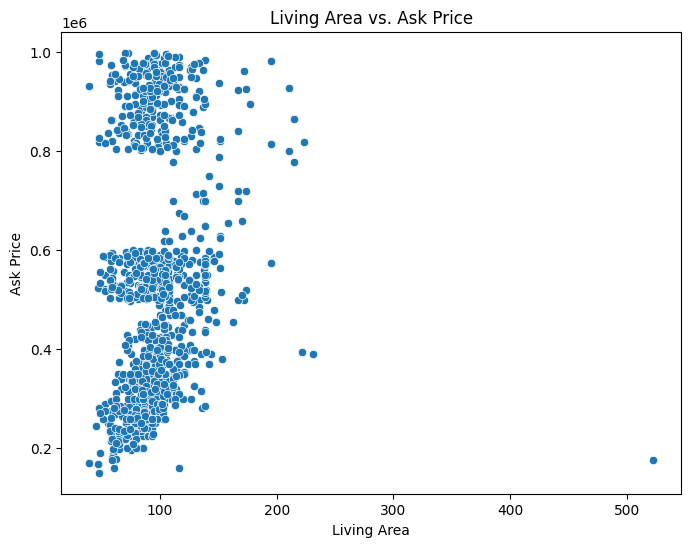

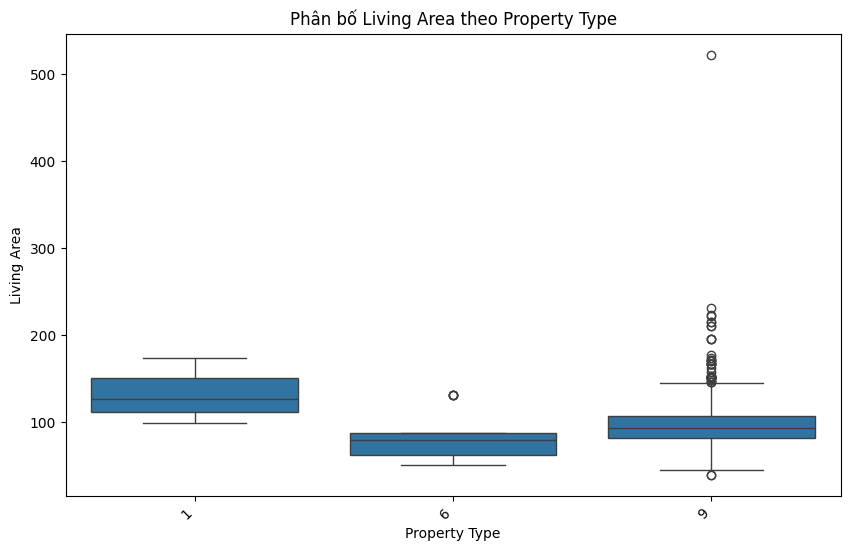

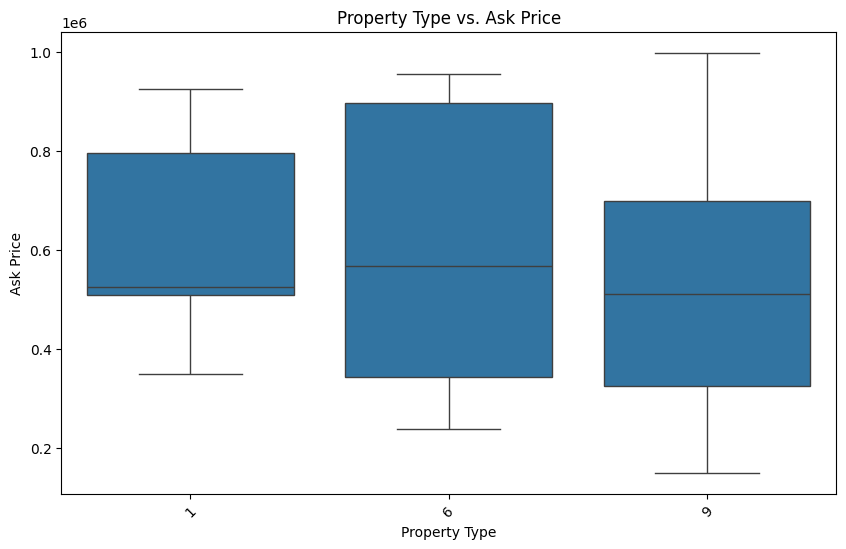

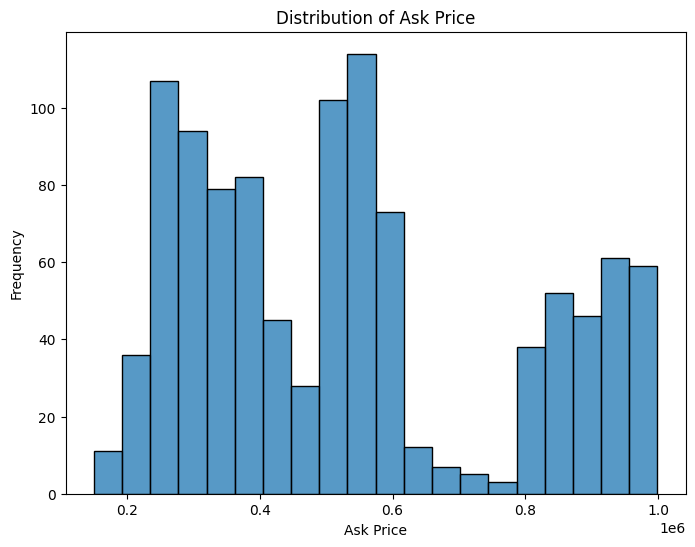

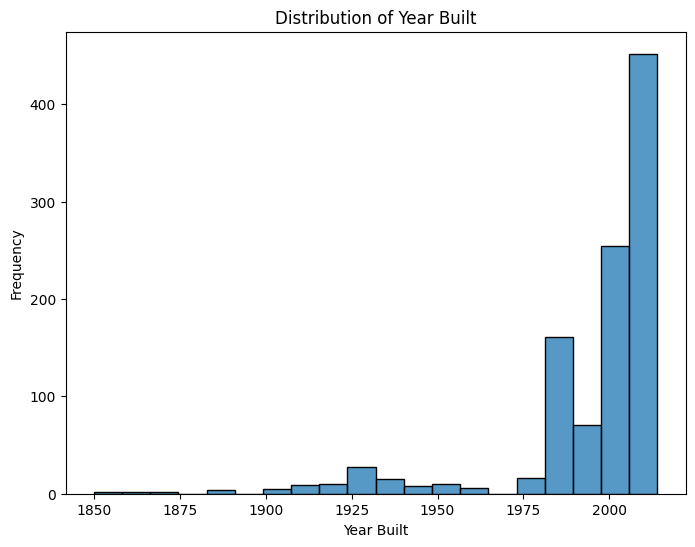

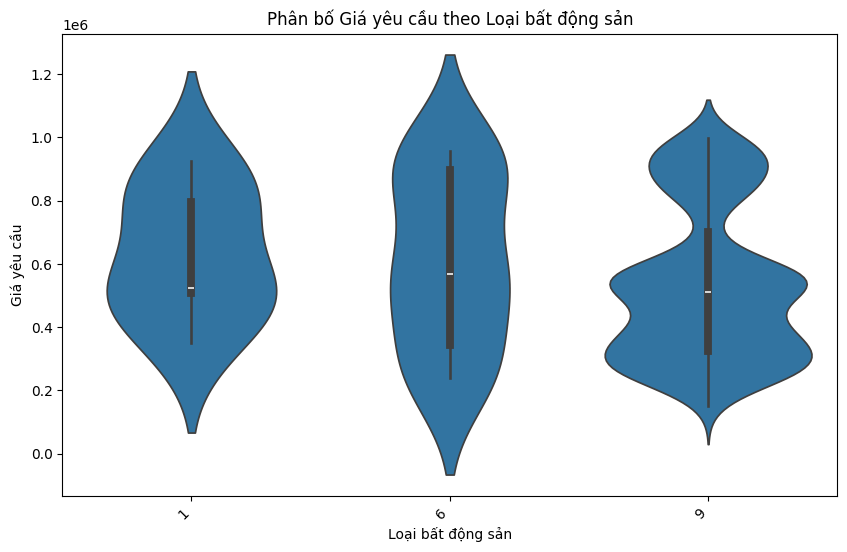

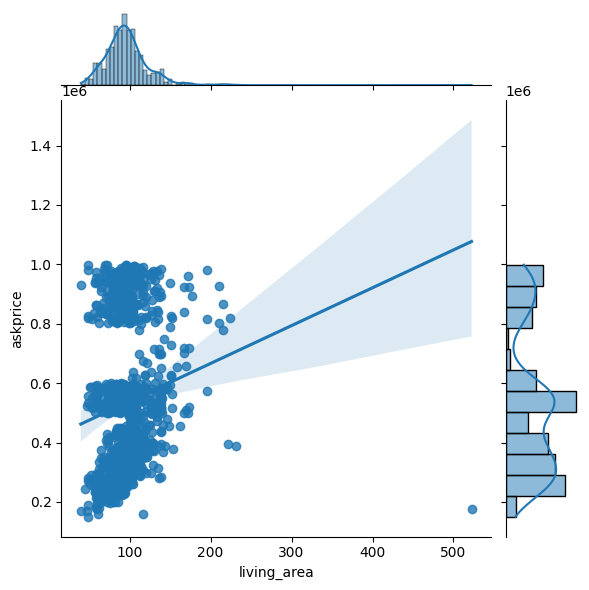

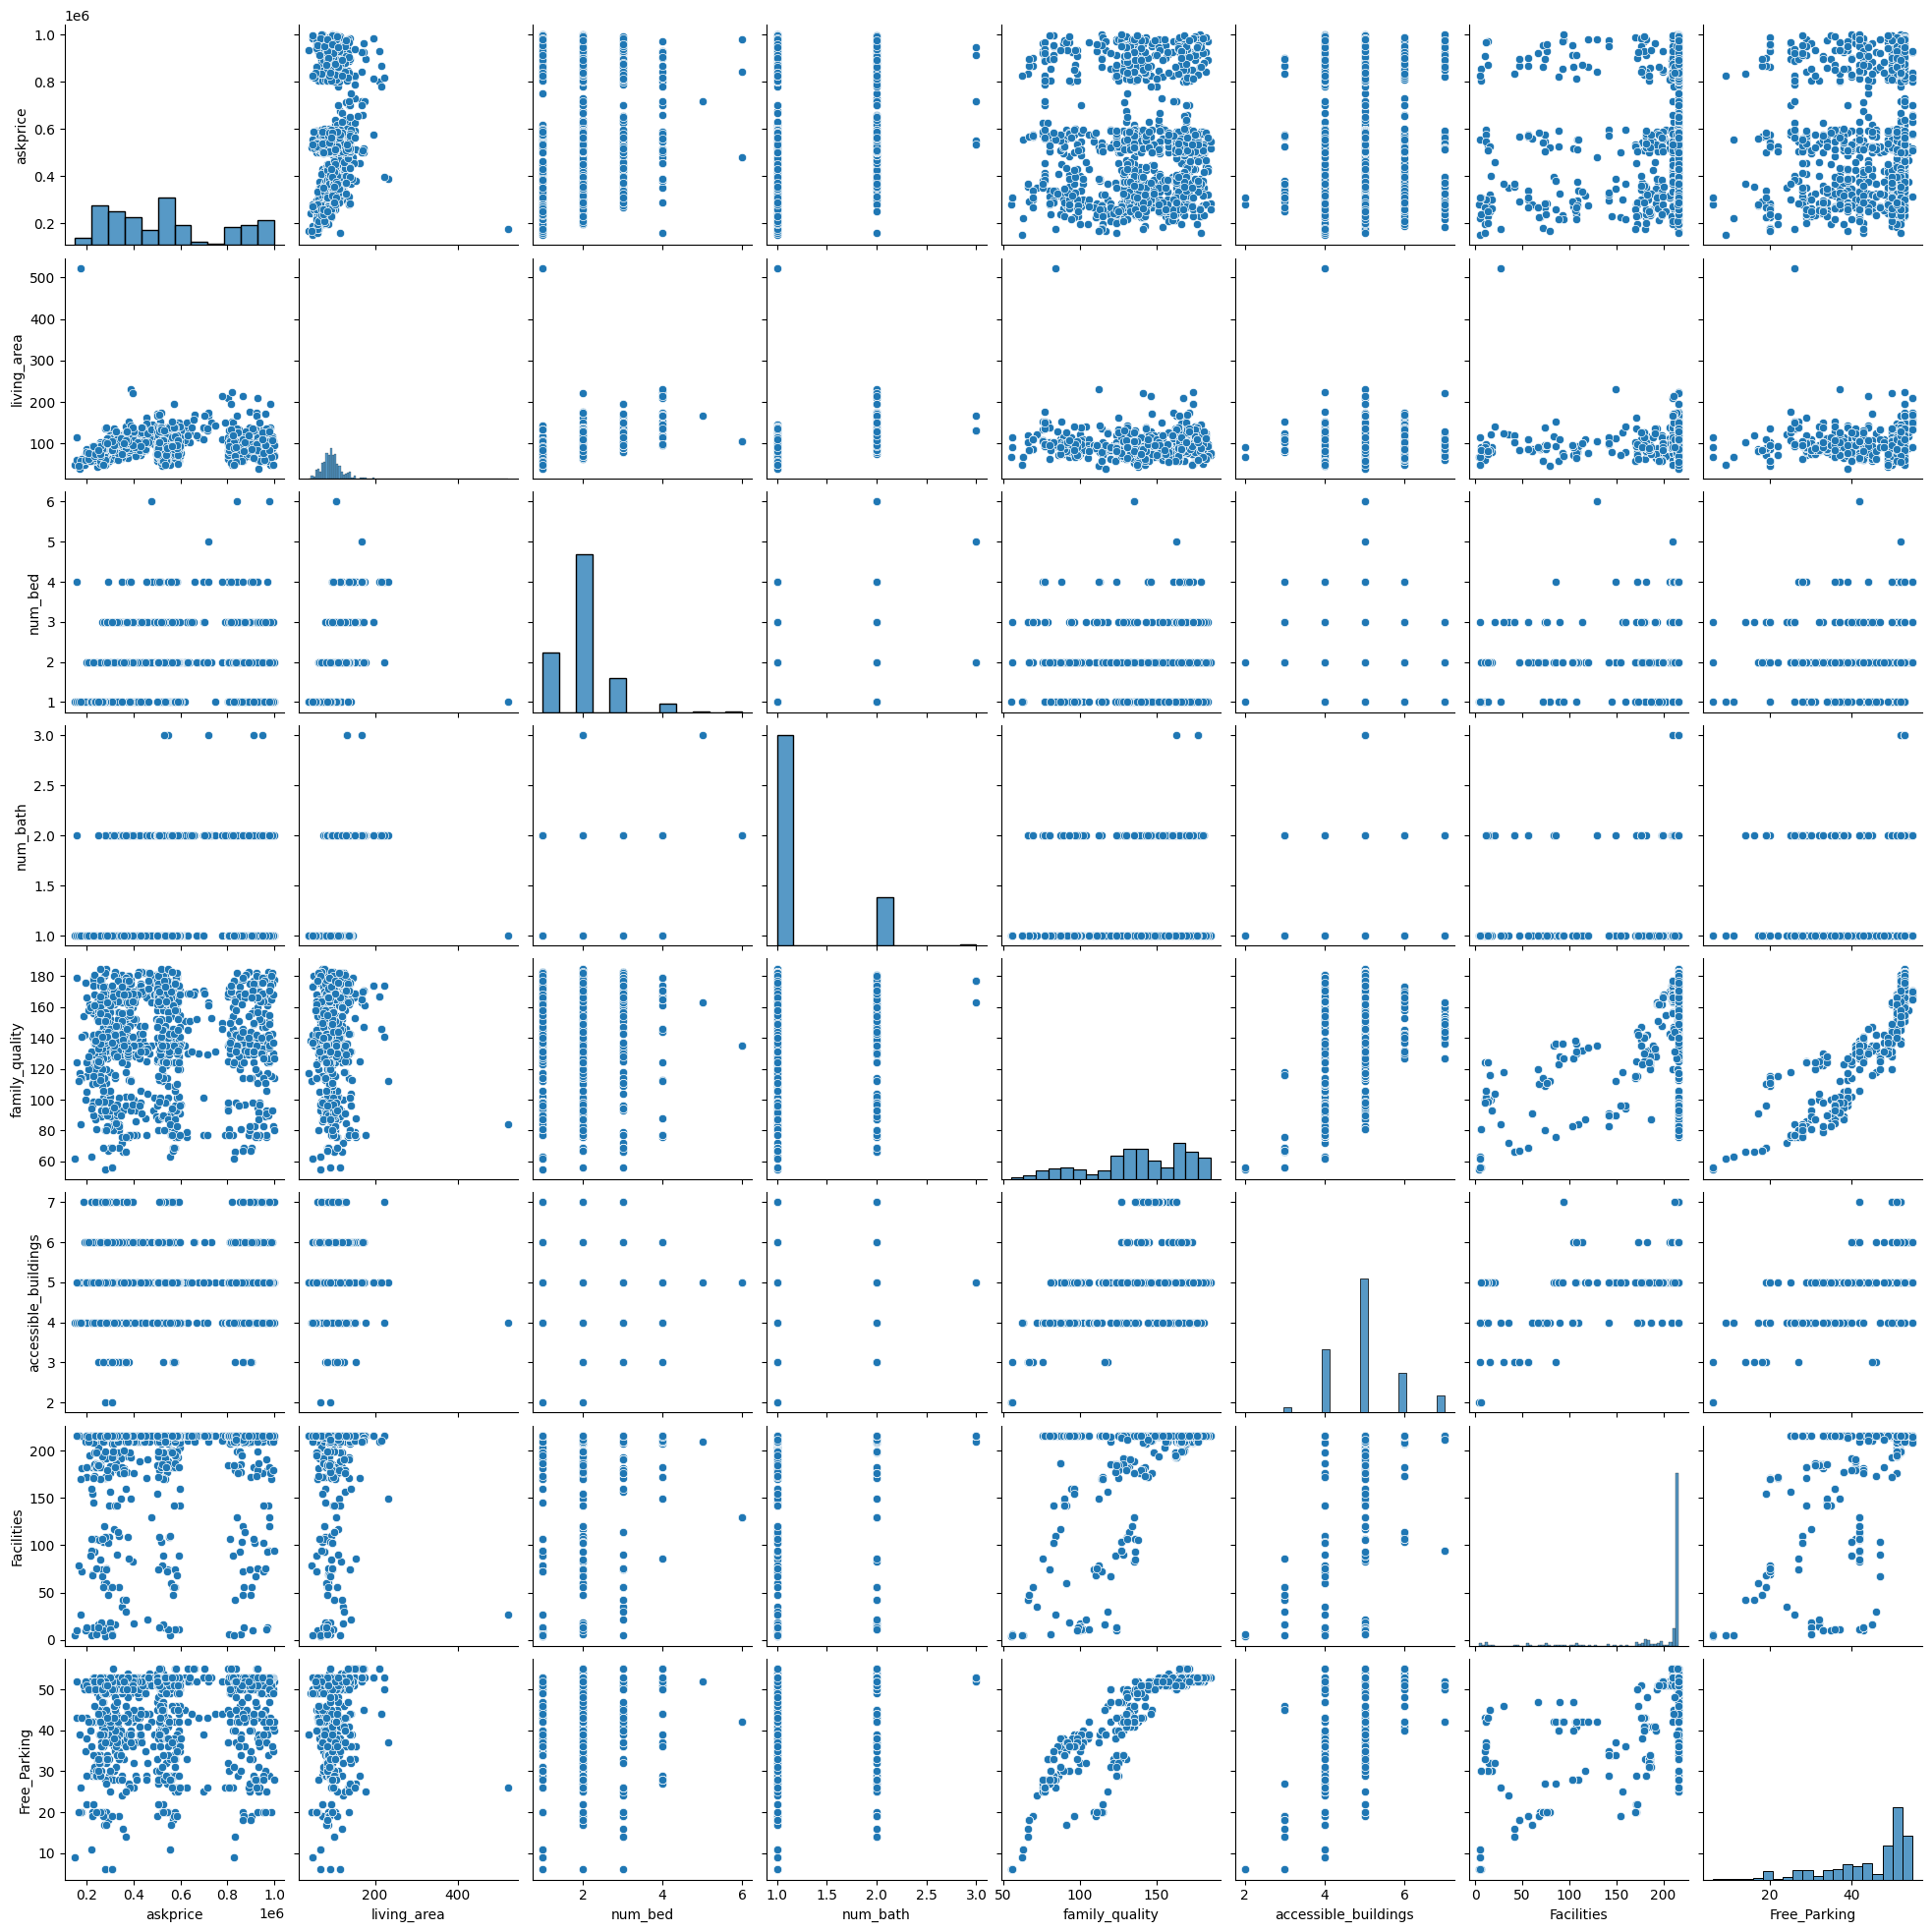

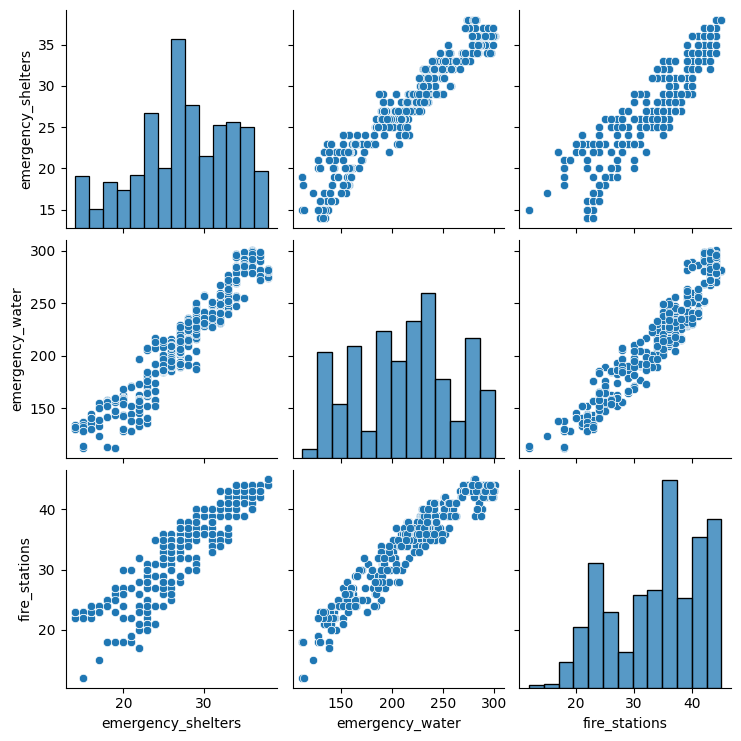

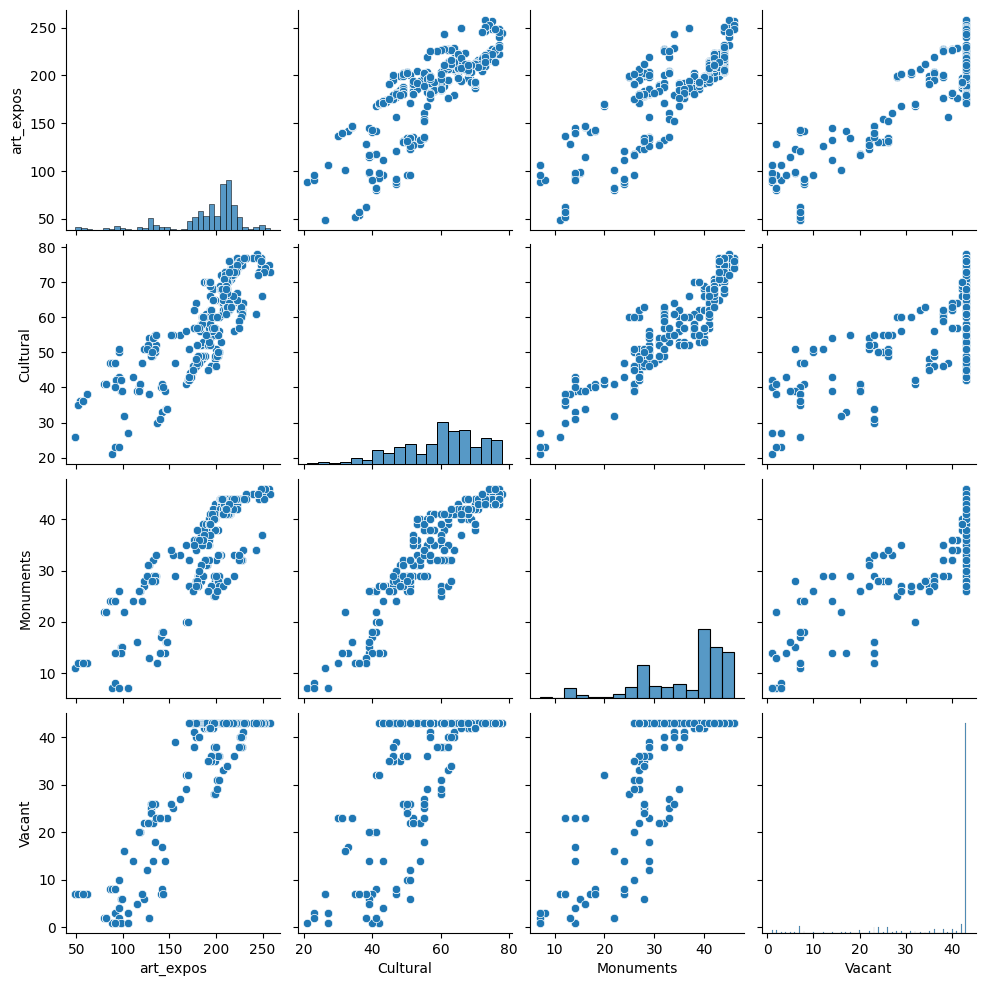

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Biểu đồ phân tán cho living area vs. askprice
plt.figure(figsize=(8, 6))
sns.scatterplot(x='living_area', y='askprice', data=df)
plt.title('Living Area vs. Ask Price')
plt.xlabel('Living Area')
plt.ylabel('Ask Price')
plt.show()

# Biểu đồ hộp
plt.figure(figsize=(10, 6))  # Điều chỉnh kích thước biểu đồ
sns.boxplot(x='property_type', y='living_area', data=df)
plt.title('Phân bố Living Area theo Property Type')
plt.xlabel('Property Type')
plt.ylabel('Living Area')
plt.xticks(rotation=45, ha='right')  # Xoay nhãn trục x nếu cần
plt.show()



# Biểu đồ hộp cho property type vs. askprice
plt.figure(figsize=(10, 6))
sns.boxplot(x='property_type', y='askprice', data=df)
plt.title('Property Type vs. Ask Price')
plt.xlabel('Property Type')
plt.ylabel('Ask Price')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

# Biểu đồ tần suất cho askprice distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['askprice'], bins=20)  # Adjust bins as needed
plt.title('Distribution of Ask Price')
plt.xlabel('Ask Price')
plt.ylabel('Frequency')
plt.show()

# Biểu đồ tần suất
plt.figure(figsize=(8, 6))
sns.histplot(df['year_built'], bins=20)  # Adjust bins as needed
plt.title('Distribution of Year Built')
plt.xlabel('Year Built')
plt.ylabel('Frequency')
plt.show()

# Biểu đồ violin
plt.figure(figsize=(10, 6))
sns.violinplot(x='property_type', y='askprice', data=df)
plt.title('Phân bố Giá yêu cầu theo Loại bất động sản')
plt.xlabel('Loại bất động sản')
plt.ylabel('Giá yêu cầu')
plt.xticks(rotation=45, ha='right')  # Xoay nhãn trục x nếu cần
plt.show()

# Biểu đồ kết hợp
sns.jointplot(x='living_area', y='askprice', data=df, kind='reg')
plt.show()

# Biểu đồ cặp
numerical_features = ['askprice', 'living_area', 'num_bed', 'num_bath', 'family_quality', 'accessible_buildings','Facilities','Free_Parking']  # Chọn các thuộc tính số
sns.pairplot(df[numerical_features])
plt.show()

numerical_features = [ 'emergency_shelters','emergency_water','fire_stations']  # Chọn các thuộc tính số
sns.pairplot(df[numerical_features])
plt.show()

numerical_features = ['art_expos', 'Cultural','Monuments', 'Vacant']  # Chọn các thuộc tính số
sns.pairplot(df[numerical_features])
plt.show()


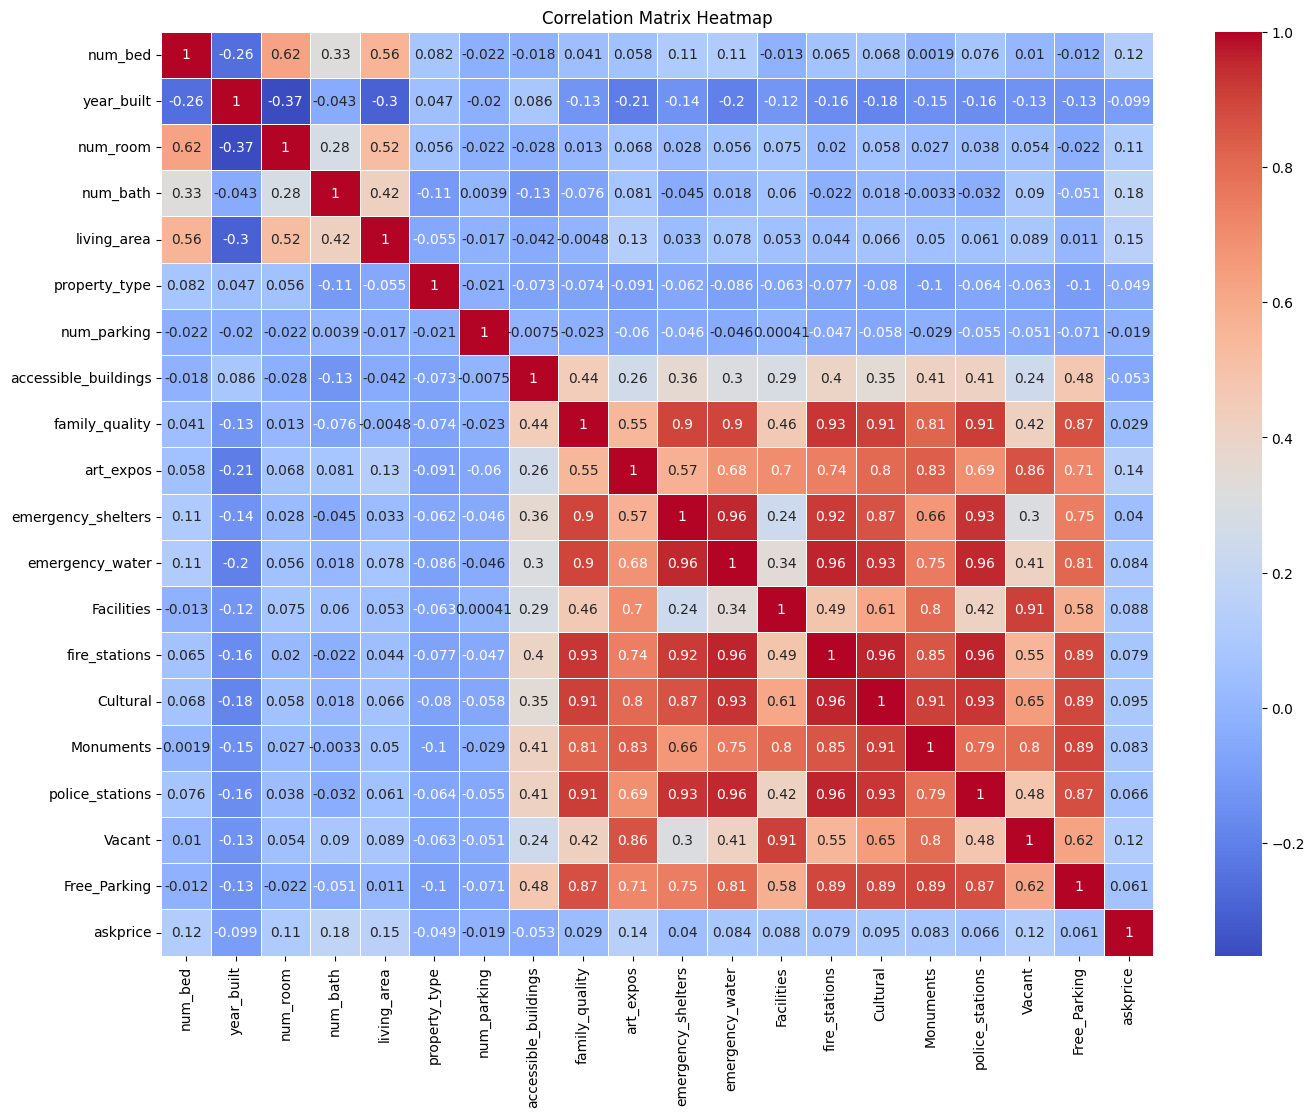

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# bỏ cột longtitude=kinh độ và latitude=vĩ độ
df=df.drop(columns=['longitude','latitude'])
# Tính toán ma trận tương quan
correlation_matrix = df.corr()

# Vẽ heatmap
plt.figure(figsize=(16, 12))  # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
# 'askprice' là biến mục tiêu và các cột còn lại là features
X = df.drop('askprice', axis=1)
y = df['askprice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Kích thước tập train:", X_train.shape, y_train.shape)
print("Kích thước tập test:", X_test.shape, y_test.shape)

Kích thước tập train: (843, 19) (843,)
Kích thước tập test: (211, 19) (211,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numerical_features = X_train.select_dtypes(include=np.number).columns

X_train_scaled = X_train.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])

X_test_scaled = X_test.copy()
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

# Hiển thị kích thước tập dữ liệu sau khi chuẩn hóa
print("Kích thước tập train sau khi chuẩn hóa:", X_train_scaled.shape)
print("Kích thước tập test sau khi chuẩn hóa:", X_test_scaled.shape)

Kích thước tập train sau khi chuẩn hóa: (843, 19)
Kích thước tập test sau khi chuẩn hóa: (211, 19)


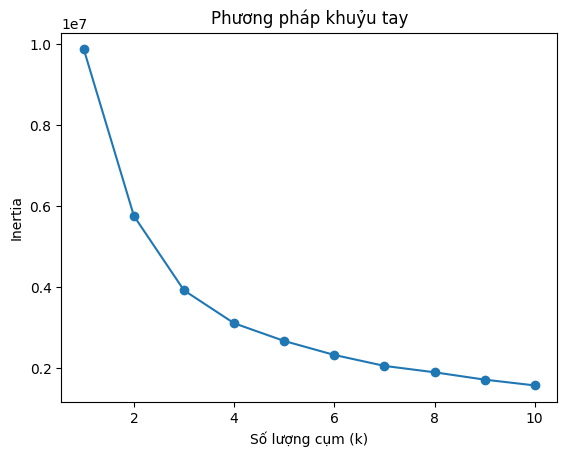

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
# phương pháp khuỷu tay để tìm số cụm tối ưu
inertia_values = []
k_values = range(1, 11)  # Thử nghiệm với k từ 1 đến 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

plt.plot(k_values, inertia_values, marker='o')
plt.xlabel("Số lượng cụm (k)")
plt.ylabel("Inertia")
plt.title("Phương pháp khuỷu tay")
plt.show()




In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

# Khởi tạo KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)

# Thực hiện xử lý missing values cho dữ liệu huấn luyện và kiểm tra
X_train_scaled[numerical_features] = knn_imputer.fit_transform(X_train_scaled[numerical_features])
X_test_scaled[numerical_features] = knn_imputer.transform(X_test_scaled[numerical_features])

# Số lượng mẫu ban đầu
print(f"Số lượng mẫu ban đầu: {X_train_scaled.shape[0]}")

# ======== XỬ LÝ NGOẠI LỆ (DÙNG CLIP THAY VÌ LOẠI BỎ) ========
# phân vị là các điểm cắt chia phạm vi của phân phối xác suất thành các khoảng liên tục có xác suất bằng nhau
Q1 = X_train_scaled[numerical_features].quantile(0.25)
Q3 = X_train_scaled[numerical_features].quantile(0.75)
IQR = Q3 - Q1

# Giới hạn giá trị thay vì loại bỏ
X_train_scaled[numerical_features] = X_train_scaled[numerical_features].clip(
    lower=(Q1 - 1.5 * IQR).to_numpy(),
    upper=(Q3 + 1.5 * IQR).to_numpy(),
    axis=1
)

# Số lượng mẫu sau khi xử lý (vẫn giữ nguyên vì không loại bỏ)
print(f"Số lượng mẫu sau khi xử lý ngoại lệ: {X_train_scaled.shape[0]}")

# ======== ÁP DỤNG PCA ========
pca = PCA(n_components=2)  # Giảm xuống 2 chiều để dễ phân cụm
X_train_pca = pca.fit_transform(X_train_scaled[numerical_features])
X_test_pca = pca.transform(X_test_scaled[numerical_features])



Số lượng mẫu ban đầu: 843
Số lượng mẫu sau khi xử lý ngoại lệ: 843


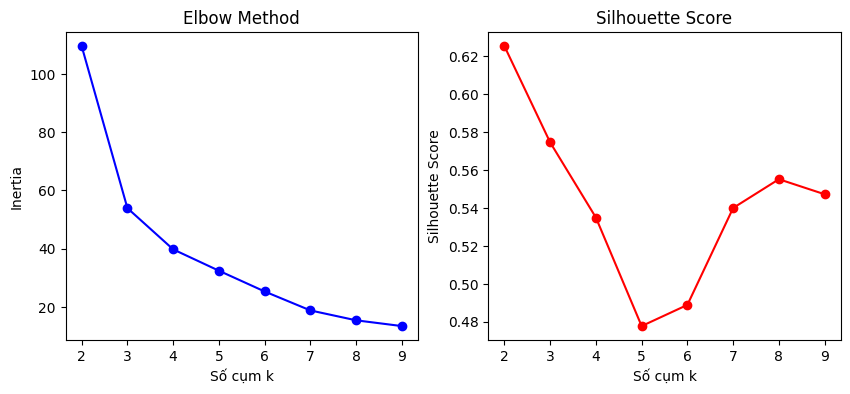

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

distortions = []
silhouette_scores = []
K_range = range(2, 10)  # Thử các giá trị k từ 2 đến 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=50, random_state=42)
    kmeans.fit(X_train_pca)
    distortions.append(kmeans.inertia_)  # Tính toán độ méo (Inertia)
    silhouette_scores.append(silhouette_score(X_train_pca, kmeans.labels_))

# Vẽ Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, distortions, 'bo-')
plt.xlabel('Số cụm k')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Vẽ Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Số cụm k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.show()


In [ ]:

# ======== K-Means Clustering ========
# Phân nhóm askprice thành 3 cụm dựa trên khoảng giá trị
bin_edges = pd.qcut(y_train, q=3, retbins=True)[1]  # Lấy ra khoảng giá trị

# Gán nhãn cụm dựa trên giá trị thực tế của askprice
y_train_bins = pd.cut(y_train, bins=bin_edges, labels=[0, 1, 2], include_lowest=True)
y_test_bins = pd.cut(y_test, bins=bin_edges, labels=[0, 1, 2], include_lowest=True)

# Hiển thị khoảng giá của mỗi cụm
print("Khoảng giá trị của các cụm:")
for i in range(len(bin_edges) - 1):
    print(f"Cụm {i}: {bin_edges[i]:,.0f} - {bin_edges[i+1]:,.0f}")

k = 3  # Hoặc chọn k tối ưu bằng Elbow Method trước
kmeans_pca = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=42)
kmeans_pca.fit(X_train_pca)

# Dự đoán nhãn cụm cho tập huấn luyện
train_cluster_labels = kmeans_pca.predict(X_train_pca)

# Dự đoán nhãn cụm cho tập kiểm tra
test_cluster_labels = kmeans_pca.predict(X_test_pca)

# So sánh
train_comparison = pd.DataFrame({'Actual_Price': y_train, 'Predicted_Cluster': train_cluster_labels, 'True_Cluster': y_train_bins.values})
test_comparison = pd.DataFrame({'Actual_Price': y_test, 'Predicted_Cluster': test_cluster_labels, 'True_Cluster': y_test_bins.values})

# Hiển thị kết quả so sánh
print("Training Data Comparison:")
display(train_comparison)

print("\nTesting Data Comparison:")
display(test_comparison)

# Đếm số lượng điểm trong mỗi cụm
unique, counts = np.unique(train_cluster_labels, return_counts=True)

# Hiển thị phân phối cụm
cluster_distribution = pd.DataFrame({'Cluster': unique, 'Num_Points': counts})
print("\nCluster Distribution:")
print(cluster_distribution)



Khoảng giá trị của các cụm:
Cụm 0: 150,000 - 379,267
Cụm 1: 379,267 - 577,477
Cụm 2: 577,477 - 998,924
Training Data Comparison:


,Actual_Price,Predicted_Cluster,True_Cluster
321,296500,1,0
757,524709,2,1
442,259000,0,0
362,323000,0,0
377,435000,2,1
...,...,...,...
330,325000,0,0
466,349900,2,0
121,449000,1,1
1044,960222,1,2



Testing Data Comparison:


,Actual_Price,Predicted_Cluster,True_Cluster
260,325000,2,0
1025,863626,2,2
845,864028,2,2
1005,910766,2,2
88,319000,2,0
...,...,...,...
25,220000,2,0
72,259900,1,0
918,973621,2,2
44,269000,2,0



Cluster Distribution:
   Cluster  Num_Points
0        0         285
1        1         228
2        2         330


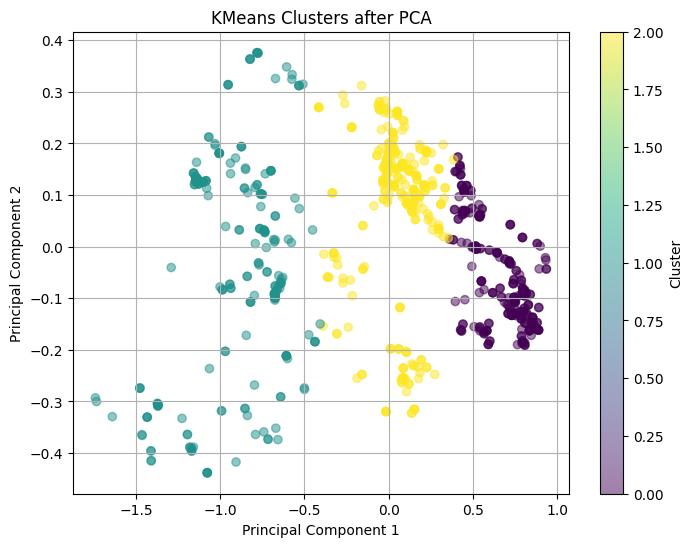

In [ ]:
# Vẽ biểu đồ với màu sắc khác nhau cho mỗi cụm dự đoán
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_cluster_labels, cmap='viridis', alpha=0.5)

# Thêm tiêu đề và nhãn
plt.title("KMeans Clusters after PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Tính Silhouette Score cho dữ liệu huấn luyện
silhouette_train = silhouette_score(X_train_pca, train_cluster_labels)
print(f"Silhouette Score for Training Data: {silhouette_train}")

# Tính Silhouette Score cho dữ liệu kiểm tra
silhouette_test = silhouette_score(X_test_pca, test_cluster_labels)
print(f"Silhouette Score for Test Data: {silhouette_test}")

Silhouette Score for Training Data: 0.5745914118846145
Silhouette Score for Test Data: 0.5519655534918066


In [ ]:
from sklearn.metrics import silhouette_score # Import silhouette_score

train_cluster_labels_pca = kmeans_pca.labels_
silhouette_cleaned = silhouette_score(X_train_pca, train_cluster_labels_pca)
print(f'Silhouette Score : {silhouette_cleaned:.4f}')

# Tính điểm Inertia của mô hình KMeans
inertia_cleaned = kmeans_pca.inertia_
print(f'Inertia: {inertia_cleaned:.4f}')

Silhouette Score : 0.5746
Inertia: 53.9258


In [ ]:
num_bed = 2  # @param {"type": "number"}
year_built = 1927  # @param {"type": "number"}
num_room = 3  # @param {"type": "number"}
num_bath = 1  # @param {"type": "number"}
living_area = 94  # @param {"type": "number"}
property_type = 6  # @param {"type": "number"}
num_parking = 1  # @param {"type": "number"}
accessible_buildings = 5  # @param {"type": "number"}
family_quality = 137  # @param {"type": "number"}
art_expos = 213  # @param {"type": "number"}
emergency_shelters = 27  # @param {"type": "number"}
emergency_water = 213  # @param {"type": "number"}
Facilities = 104  # @param {"type": "number"}
fire_stations = 37  # @param {"type": "number"}
Cultural = 69  # @param {"type": "number"}
Monuments = 41  # @param {"type": "number"}
police_stations = 17  # @param {"type": "number"}
Vacant = 43  # @param {"type": "number"}
Free_Parking = 48  # @param {"type": "number"}

numerical_features = numerical_features.drop(['longitude', 'latitude'], errors='ignore')

# Tạo mảng numpy từ dữ liệu trên
# Chuyển dữ liệu thành mảng numpy
input_data = np.array([
    num_bed, year_built, num_room, num_bath, living_area,
    property_type, num_parking, accessible_buildings, family_quality, art_expos,
    emergency_shelters, emergency_water, Facilities, fire_stations, Cultural,
    Monuments, police_stations, Vacant, Free_Parking
])
input_data_df = pd.DataFrame(input_data.reshape(1, -1), columns=numerical_features)

# Scale the input data using the same scaler used for training
input_data_df[numerical_features] = scaler.transform(input_data_df[numerical_features])

# Apply PCA to reduce the input data to 2 features
input_data_pca = pca.transform(input_data_df[numerical_features])

# Now use kmeans_pca (trained on PCA data) for prediction
predicted_cluster = kmeans_pca.predict(input_data_pca)

print(f"Predicted Cluster: {predicted_cluster[0]}")



Predicted Cluster: 2


In [ ]:
print(train_comparison.groupby('Predicted_Cluster')['Actual_Price'].describe())


                   count           mean            std       min       25%  \
Predicted_Cluster                                                            
0                  285.0  565427.414035  228927.249668  159000.0  385000.0   
1                  228.0  517097.179825  245581.543327  150000.0  293700.0   
2                  330.0  538059.400000  249071.737805  169000.0  317250.0   

                        50%       75%       max  
Predicted_Cluster                                
0                  519726.0  806297.0  998877.0  
1                  517424.0  598083.0  997786.0  
2                  512610.5  809693.0  998924.0  


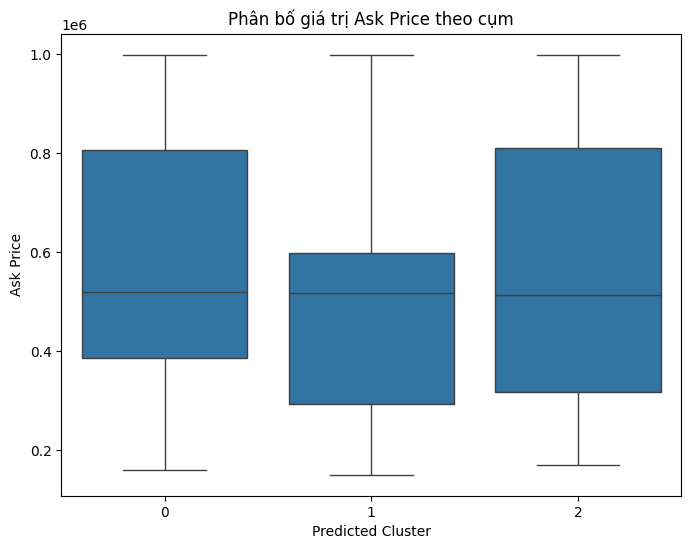

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x=train_comparison['Predicted_Cluster'], y=train_comparison['Actual_Price'])
plt.title("Phân bố giá trị Ask Price theo cụm")
plt.xlabel("Predicted Cluster")
plt.ylabel("Ask Price")
plt.show()